In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect('dubai_transit.db')

In [2]:
routes = pd.read_csv('routes.txt')
stops = pd.read_csv('stops.txt')
trips = pd.read_csv('trips.txt')
stop_times = pd.read_csv('stop_times.txt')
shapes = pd.read_csv('shapes.txt')
calendar = pd.read_csv('calendar.txt')
# calendar_dates = pd.read_csv('calendar_dates.txt')
transfers = pd.read_csv('transfers.txt')
# agency = pd.read_csv('agency.txt')

for name, df in [('routes', routes), ('stops', stops), ('trips', trips),
                  ('stop_times', stop_times), ('shapes', shapes),
                  ('calendar', calendar), ('transfers', transfers)]:
    print(name, df.shape)


/tmp/ipykernel_825/3374184053.py:3: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  trips = pd.read_csv('trips.txt')


routes (201, 7)
stops (2819, 9)
trips (66562, 8)
stop_times (1436290, 9)
shapes (185237, 5)
calendar (18, 10)
transfers (1002, 4)


In [3]:
route_type_map = {
    0: 'Tram',
    1: 'Metro',
    3: 'Bus',
    4: 'Ferry'
}
routes['mode'] = routes['route_type'].map(route_type_map)
print(routes['mode'].value_counts())

mode
Bus      182
Ferry     15
Metro      3
Tram       1
Name: count, dtype: int64


In [4]:
routes.to_sql('routes', conn, if_exists='replace', index=False)
stops.to_sql('stops', conn, if_exists='replace', index=False)
trips.to_sql('trips', conn, if_exists='replace', index=False)
stop_times.to_sql('stop_times', conn, if_exists='replace', index=False)
shapes.to_sql('shapes', conn, if_exists='replace', index=False)
calendar.to_sql('calendar', conn, if_exists='replace', index=False)
transfers.to_sql('transfers', conn, if_exists='replace', index=False)

print("Tables loaded successfully")

Tables loaded successfully


In [5]:
stops_by_mode = """
SELECT r.mode, COUNT(DISTINCT st.stop_id) as stop_count
FROM stop_times st
JOIN trips t on st.trip_id = t.trip_id
JOIN routes r on t.route_id = r.route_id
GROUP BY r.mode
ORDER BY stop_count
"""

pd.read_sql(stops_by_mode, conn)

,mode,stop_count
0,Tram,19
1,Ferry,25
2,Metro,112
3,Bus,2663


In [6]:
kpi_query = """
SELECT
    (SELECT COUNT(*) FROM routes) AS total_routes,
    (SELECT COUNT(*) FROM stops) AS total_stops,
    (SELECT COUNT(*) FROM trips) AS total_trips
"""
pd.read_sql(kpi_query, conn)

,total_routes,total_stops,total_trips
0,201,2819,66562


In [7]:
modes_query = """
SELECT COUNT(DISTINCT mode) as total_modes
FROM routes
"""
pd.read_sql(modes_query, conn)

,total_modes
0,4


    mode  route_count
0    Bus          182
1  Ferry           15
2  Metro            3
3   Tram            1


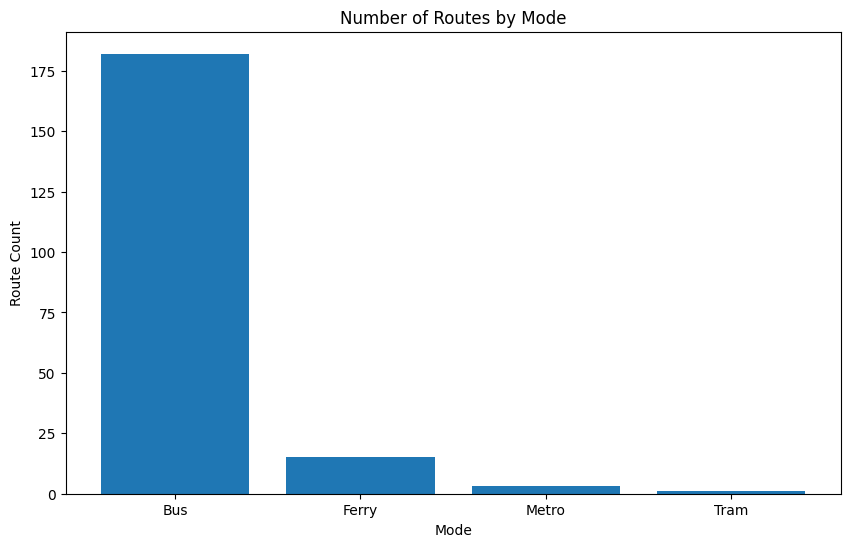

In [8]:
routes_by_mode = """
SELECT mode, COUNT(*) as route_count
FROM routes
GROUP BY mode
"""
data = pd.read_sql(routes_by_mode, conn)
print(data)
plt.figure(figsize=(10,6))
plt.bar(data['mode'], data['route_count'])
plt.xlabel('Mode')
plt.ylabel('Route Count')
plt.title('Number of Routes by Mode')
plt.show()

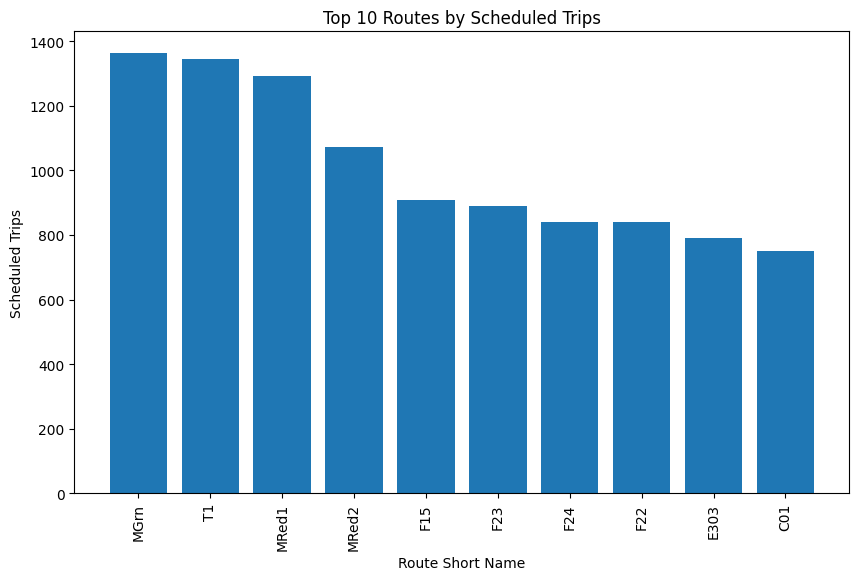

In [9]:
top_routes = """
SELECT r.route_short_name, r.route_long_name, r.mode, COUNT(t.trip_id) as scheduled_trips
FROM routes r
JOIN trips t on r.route_id = t.route_id
GROUP BY r.route_short_name, r.route_long_name, r.mode
ORDER BY scheduled_trips DESC
LIMIT 10
"""
top_routes_data = pd.read_sql(top_routes, conn)
plt.figure(figsize = (10,6))
plt.bar(top_routes_data['route_short_name'], top_routes_data['scheduled_trips'])
plt.xlabel('Route Short Name')
plt.ylabel('Scheduled Trips')
plt.title('Top 10 Routes by Scheduled Trips')
plt.xticks(rotation=90)
plt.show()

In [10]:
print("Missing latitude:", stops['stop_lat'].isna().sum())
print("Missing longitude:", stops['stop_lon'].isna().sum())
print("Duplicate stop IDs:",
      stops['stop_id'].duplicated().sum())

Missing latitude: 0
Missing longitude: 0
Duplicate stop IDs: 0


In [11]:
stops_by_mode = """
SELECT DISTINCT s.stop_id, s.stop_name, s.stop_lat, s.stop_lon, r.mode
FROM stops s
JOIN stop_times st on s.stop_id = st.stop_id
JOIN trips t on st.trip_id = t.trip_id
JOIN routes r on t.route_id = r.route_id
"""
stop_mode_data = pd.read_sql(stops_by_mode, conn)
print(stop_mode_data.shape)
stop_mode_data.head()

(2819, 5)


,stop_id,stop_name,stop_lat,stop_lon,mode
0,12801,centrepoint Metro Station 1,25.230103,55.391580,Metro
1,12802,centrepoint Metro Station 2,25.230130,55.391501,Metro
2,12901,Emirates Metro Station 1,25.241097,55.365720,Metro
3,12902,Emirates Metro Station 2,25.241151,55.365611,Metro
4,13001,Airport Terminal 3 Metro Station 1,25.245142,55.359428,Metro


In [12]:
stop_mode_data.to_csv('dubai_transit_stops_map.csv', index=False)

In [13]:
print(stops.columns.tolist())
print(stops['zone_id'].value_counts() if 'zone_id' in stops.columns else "No zone_id column")

['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'zone_id', 'location_type', 'stop_code', 'stop_desc', 'stop_url']
zone_id
5        713
2        550
4        411
6        403
1        333
        ... 
29801      1
30801      1
29901      1
30601      1
30501      1
Name: count, Length: 71, dtype: int64


In [14]:
trips_by_hour = """
SELECT CAST(SUBSTR(arrival_time, 1, 2) AS INTEGER) AS hour, COUNT(DISTINCT trip_id) AS trip_count
FROM stop_times
GROUP BY hour
ORDER BY hour
"""
trips_hour_data = pd.read_sql(trips_by_hour, conn)
trips_hour_data

,hour,trip_count
0,3,26
1,4,370
2,5,1644
3,6,4294
4,7,6303
5,8,7202
6,9,7255
7,10,6811
8,11,6245
9,12,6080


    hour  trip_count
0      0        2072
1      1         634
2      2         266
3      3         206
4      4         500
5      5        1721
6      6        4324
7      7        6310
8      8        7202
9      9        7255
10    10        6811
11    11        6245
12    12        6080
13    13        6014
14    14        6177
15    15        6543
16    16        7310
17    17        8005
18    18        8459
19    19        8450
20    20        8119
21    21        7345
22    22        6171
23    23        4345


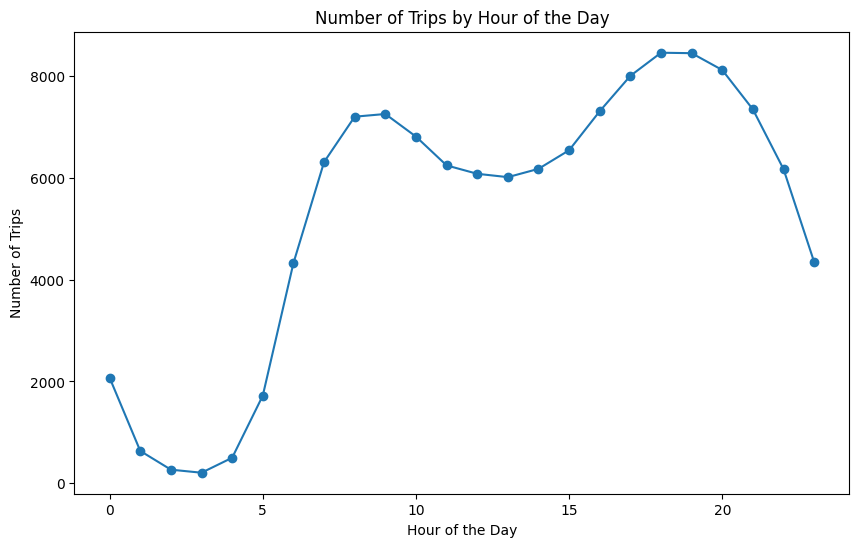

In [15]:
trips_by_hour_24 = """
SELECT
  CASE
    WHEN CAST(SUBSTR(arrival_time, 1, 2) AS INTEGER) >= 24
    THEN CAST(SUBSTR(arrival_time, 1, 2) AS INTEGER) - 24
    ELSE CAST(SUBSTR(arrival_time, 1, 2) AS INTEGER)
  END AS hour,
  COUNT(DISTINCT trip_id) AS trip_count
FROM stop_times
GROUP BY hour
ORDER BY hour
"""
trips_hour_data_24 = pd.read_sql(trips_by_hour_24, conn)
print(trips_hour_data_24)

plt.figure(figsize=(10,6))
plt.plot(trips_hour_data_24['hour'], trips_hour_data_24['trip_count'], marker='o')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.title('Number of Trips by Hour of the Day')
plt.show()

         day  trip_count
0     Monday       14332
1    Tuesday       14332
2  Wednesday       14332
3   Thursday       14332
4     Friday       14220
5   Saturday       13103
6     Sunday       11641


Text(0.5, 1.0, 'Number of trips by day of the week')

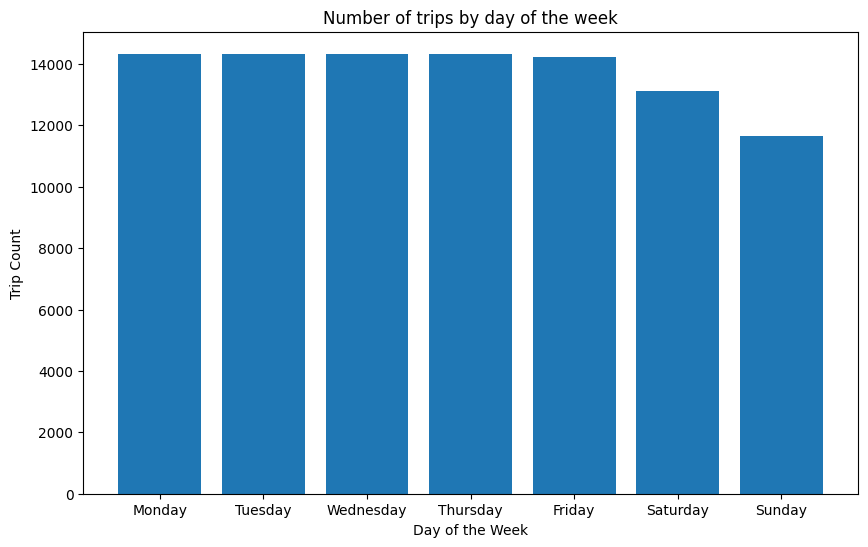

In [16]:
trips_by_day_query = """
SELECT 'Monday' AS day, COUNT(t.trip_id) AS trip_count
FROM trips t JOIN calendar c ON t.service_id = c.service_id WHERE c.monday = 1
UNION ALL
SELECT 'Tuesday', COUNT(t.trip_id)
FROM trips t JOIN calendar c ON t.service_id = c.service_id WHERE c.tuesday = 1
UNION ALL
SELECT 'Wednesday', COUNT(t.trip_id)
FROM trips t JOIN calendar c ON t.service_id = c.service_id WHERE c.wednesday = 1
UNION ALL
SELECT 'Thursday', COUNT(t.trip_id)
FROM trips t JOIN calendar c ON t.service_id = c.service_id WHERE c.thursday = 1
UNION ALL
SELECT 'Friday', COUNT(t.trip_id)
FROM trips t JOIN calendar c ON t.service_id = c.service_id WHERE c.friday = 1
UNION ALL
SELECT 'Saturday', COUNT(t.trip_id)
FROM trips t JOIN calendar c ON t.service_id = c.service_id WHERE c.saturday = 1
UNION ALL
SELECT 'Sunday', COUNT(t.trip_id)
FROM trips t JOIN calendar c ON t.service_id = c.service_id WHERE c.sunday = 1
"""
trips_by_day = pd.read_sql(trips_by_day_query, conn)
print(trips_by_day)

plt.figure(figsize=(10,6))
plt.bar(trips_by_day['day'], trips_by_day['trip_count'])
plt.xlabel('Day of the Week')
plt.ylabel('Trip Count')
plt.title('Number of trips by day of the week')

Average services in weekdays:  14309.6
Average services in weekends:  12372.0


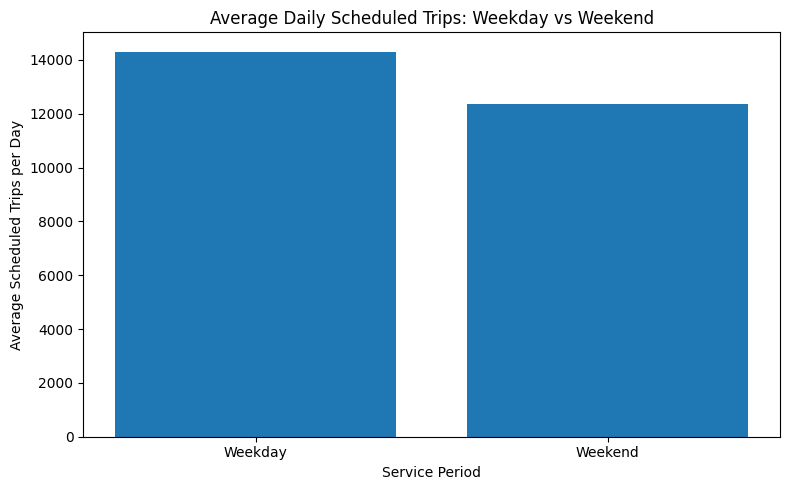

In [17]:
weekday_avg = trips_by_day[
    trips_by_day['day'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])
]['trip_count'].mean()

weekend_avg = trips_by_day[
    trips_by_day['day'].isin(['Saturday', 'Sunday'])
]['trip_count'].mean()

print('Average services in weekdays: ', weekday_avg)
print('Average services in weekends: ', weekend_avg)

weekday_weekend = pd.DataFrame({
    'service_period': ['Weekday', 'Weekend'],
    'average_daily_trips': [weekday_avg, weekend_avg]
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    weekday_weekend['service_period'],
    weekday_weekend['average_daily_trips']
)

plt.title('Average Daily Scheduled Trips: Weekday vs Weekend')
plt.xlabel('Service Period')
plt.ylabel('Average Scheduled Trips per Day')

plt.tight_layout()
plt.show()

    hour   mode  trip_count
0      0    Bus        1903
1      0  Ferry          25
2      0  Metro          66
3      0   Tram          78
4      1    Bus         622
5      1  Metro           7
6      1   Tram           5
7      2    Bus         266
8      3    Bus         206
9      4    Bus         500
10     5    Bus        1535
11     5  Metro         186
12     6    Bus        4006
13     6  Metro         266
14     6   Tram          52
15     7    Bus        5840
16     7  Ferry          48
17     7  Metro         346
18     7   Tram          76
19     8    Bus        6535


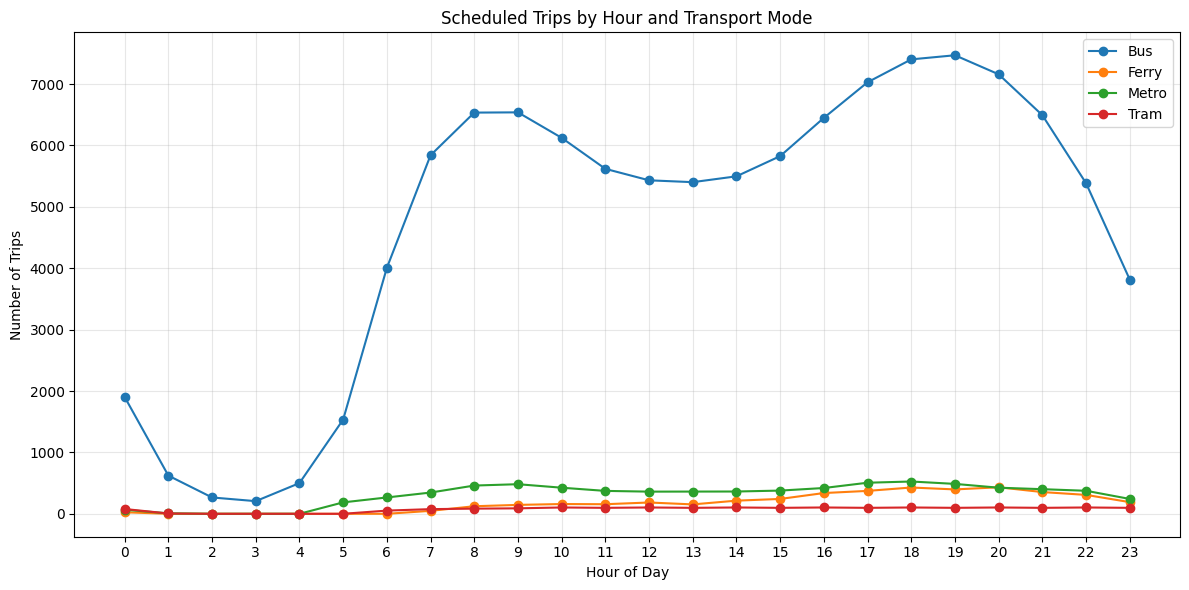

In [18]:
trips_by_hour_mode_query = """
SELECT
    CASE
        WHEN CAST(SUBSTR(st.arrival_time, 1, 2) AS INTEGER) >= 24
        THEN CAST(SUBSTR(st.arrival_time, 1, 2) AS INTEGER) - 24
        ELSE CAST(SUBSTR(st.arrival_time, 1, 2) AS INTEGER)
    END AS hour,
    r.mode,
    COUNT(DISTINCT st.trip_id) AS trip_count
FROM stop_times st
JOIN trips t ON st.trip_id = t.trip_id
JOIN routes r ON t.route_id = r.route_id
GROUP BY hour, r.mode
ORDER BY hour, r.mode
"""
trips_by_hour_mode = pd.read_sql(trips_by_hour_mode_query, conn)
print(trips_by_hour_mode.head(20))

pivot_data = trips_by_hour_mode.pivot(index='hour', columns='mode', values='trip_count').fillna(0)

plt.figure(figsize=(12, 6))
for mode in pivot_data.columns:
    plt.plot(pivot_data.index, pivot_data[mode], marker='o', label=mode)

plt.title('Scheduled Trips by Hour and Transport Mode')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

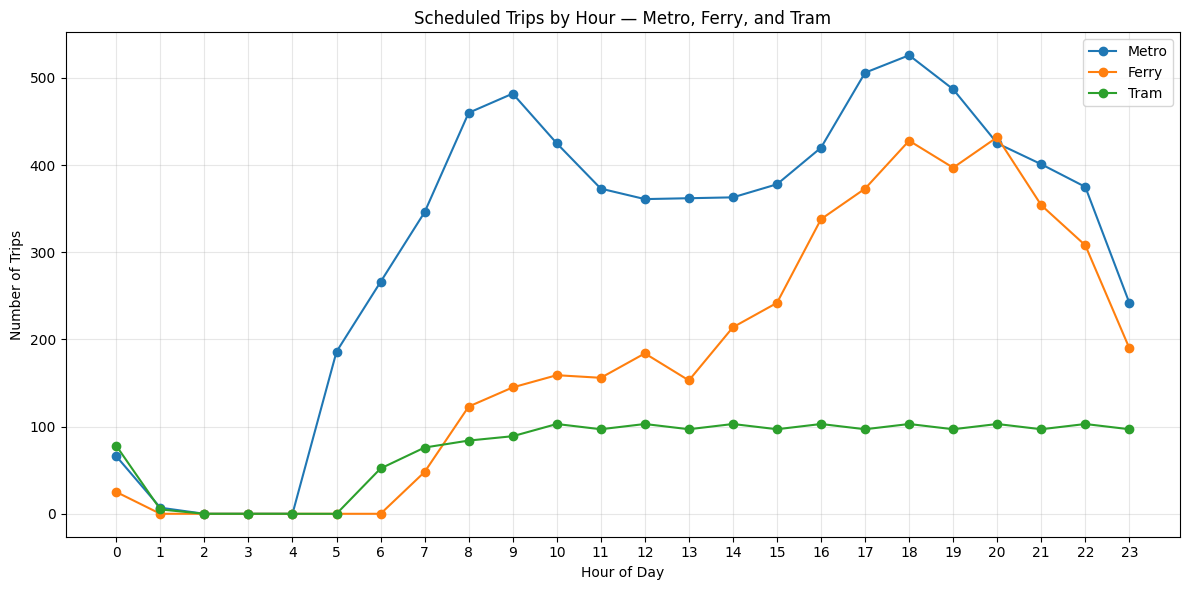

In [19]:
modes_to_plot = ['Metro', 'Ferry', 'Tram']

plt.figure(figsize=(12, 6))
for mode in modes_to_plot:
    plt.plot(pivot_data.index, pivot_data[mode], marker='o', label=mode)

plt.title('Scheduled Trips by Hour — Metro, Ferry, and Tram')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
top_transfers = """
SELECT s.stop_id, s.stop_name, COUNT(*) AS transfer_count
FROM transfers t
JOIN stops s on t.from_stop_id = s.stop_id
GROUP BY s.stop_name, s.stop_id
ORDER BY transfer_count DESC
LIMIT 15
"""
top_transfers_data = pd.read_sql(top_transfers, conn)
top_transfers_data

,stop_id,stop_name,transfer_count
0,26401,Al Ghubaiba Marine Transport Station 1,25
1,26402,Al Ghubaiba Marine Transport Station 2,25
2,17301,Al Ghubaiba Metro Station 1,25
3,17302,Al Ghubaiba Metro Station 2,25
4,100001,Gold Souq Bus Station 1,14
5,100010,Gold Souq Bus Station 10,14
6,100011,Gold Souq Bus Station 11,14
7,100012,Gold Souq Bus Station 12,14
8,100013,Gold Souq Bus Station 13,14
9,100024,Gold Souq Bus Station 24,14


In [21]:
import re
top_transfers_data['station_group'] = top_transfers_data['stop_name'].str.replace(r'\s*\d+$', '', regex=True)
print(top_transfers_data.groupby('station_group')['transfer_count'].sum().sort_values(ascending=False))

station_group
Gold Souq Bus Station                   154
Al Ghubaiba Marine Transport Station     50
Al Ghubaiba Metro Station                50
Name: transfer_count, dtype: int64


In [22]:
full_transfer_query = """
SELECT s.stop_name, COUNT(*) AS transfer_count
FROM transfers t
JOIN stops s ON t.from_stop_id = s.stop_id
GROUP BY s.stop_name
"""
all_transfers = pd.read_sql(full_transfer_query, conn)

all_transfers['station_group'] = all_transfers['stop_name'].str.replace(r'\s*\d+$', '', regex=True)
grouped_transfers = all_transfers.groupby('station_group')['transfer_count'].sum().sort_values(ascending=False).head(15)
grouped_transfers

,transfer_count
station_group,
Gold Souq Bus Station,182
Al Ghubaiba Bus Station,88
Al Ghubaiba Metro Station,50
Al Ghubaiba Marine Transport Station,50
Gold Souq Metro Station,28
Union Metro Station,28
Union Bus Station,28
Union (Green Line ) Metro Station,24
e& Metro Station,22


In [23]:
mode_pair_query = """
SELECT
    m1.mode AS from_mode,
    m2.mode AS to_mode,
    COUNT(*) AS transfer_count
FROM transfers t
JOIN (
    SELECT DISTINCT s.stop_id, r.mode
    FROM stops s
    JOIN stop_times st ON s.stop_id = st.stop_id
    JOIN trips tr ON st.trip_id = tr.trip_id
    JOIN routes r ON tr.route_id = r.route_id
) m1 ON t.from_stop_id = m1.stop_id
JOIN (
    SELECT DISTINCT s.stop_id, r.mode
    FROM stops s
    JOIN stop_times st ON s.stop_id = st.stop_id
    JOIN trips tr ON st.trip_id = tr.trip_id
    JOIN routes r ON tr.route_id = r.route_id
) m2 ON t.to_stop_id = m2.stop_id
GROUP BY from_mode, to_mode
ORDER BY transfer_count DESC
"""
mode_pairs = pd.read_sql(mode_pair_query, conn)
mode_pairs

,from_mode,to_mode,transfer_count
0,Bus,Bus,226
1,Bus,Metro,204
2,Metro,Bus,204
3,Metro,Metro,136
4,Bus,Ferry,63
5,Ferry,Bus,63
6,Bus,Tram,28
7,Tram,Bus,28
8,Tram,Tram,16
9,Metro,Tram,8


In [24]:
mode_pairs['pair'] = mode_pairs.apply(lambda x: ' ↔ '.join(sorted([x['from_mode'], x['to_mode']])), axis=1)
combined_pairs = mode_pairs.groupby('pair')['transfer_count'].sum().sort_values(ascending=False)
combined_pairs

,transfer_count
pair,
Bus ↔ Metro,408
Bus ↔ Bus,226
Metro ↔ Metro,136
Bus ↔ Ferry,126
Bus ↔ Tram,56
Metro ↔ Tram,16
Tram ↔ Tram,16
Ferry ↔ Metro,12
Ferry ↔ Tram,4


In [25]:
routes_per_stop = """
SELECT s.stop_id, s.stop_name, COUNT(DISTINCT r.route_id) as connected_routes
FROM stops s
JOIN stop_times st on s.stop_id = st.stop_id
JOIN trips t on st.trip_id = t.trip_id
JOIN routes r on t.route_id = r.route_id
GROUP BY s.stop_id
ORDER BY connected_routes DESC
LIMIT 15
"""
routes_per_stop_data = pd.read_sql(routes_per_stop, conn)
routes_per_stop_data

,stop_id,stop_name,connected_routes
0,238102,"Satwa, Masjid 2",17
1,202101,Sharaf DG Metro Bus Stop 1-1,17
2,114001,"Burj Nahar, Intersection 1",17
3,112002,Naif Intersection 2,17
4,112001,Naif Intersection 1,17
5,460001,"Satwa, Post Office",16
6,202102,Sharaf DG Metro Bus Stop 1-2,16
7,114002,"Burj Nahar, Intersection 2",16
8,407001,Nahda Street,15
9,406001,Rolla,15


In [26]:
top_hubs_table = grouped_transfers.reset_index()
top_hubs_table.columns = ['Stop/Station', 'Connected Transfers']
top_hubs_table.insert(0, 'Rank', range(1, len(top_hubs_table) + 1))
top_hubs_table

,Rank,Stop/Station,Connected Transfers
0,1,Gold Souq Bus Station,182
1,2,Al Ghubaiba Bus Station,88
2,3,Al Ghubaiba Metro Station,50
3,4,Al Ghubaiba Marine Transport Station,50
4,5,Gold Souq Metro Station,28
5,6,Union Metro Station,28
6,7,Union Bus Station,28
7,8,Union (Green Line ) Metro Station,24
8,9,e& Metro Station,22
9,10,Etisalat Bus Station,20


In [37]:
hub_map_query = """
SELECT
    s.stop_name,
    s.stop_lat,
    s.stop_lon,
    COUNT(*) AS transfer_count
FROM transfers t
JOIN stops s
    ON t.from_stop_id = s.stop_id
GROUP BY
    s.stop_id,
    s.stop_name,
    s.stop_lat,
    s.stop_lon
ORDER BY transfer_count DESC
"""

hub_map_data = pd.read_sql(hub_map_query, conn)

hub_map_data.head()

,stop_name,stop_lat,stop_lon,transfer_count
0,Al Ghubaiba Metro Station 1,25.265350,55.289177,25
1,Al Ghubaiba Metro Station 2,25.265350,55.289167,25
2,Al Ghubaiba Marine Transport Station 1,25.265418,55.291036,25
3,Al Ghubaiba Marine Transport Station 2,25.265449,55.291203,25
4,Union Metro Station 1,25.266159,55.313776,14


In [38]:
hub_map_data.to_csv('dubai_transit_hubs_map.csv', index=False)

In [29]:
routes.to_csv('dubai_transit_routes.csv', index=False)
top_routes_data.to_csv('dubai_transit_top_routes.csv', index=False)

In [30]:
trips.to_csv('dubai_transit_trips.csv', index=False)

In [31]:
trips_hour_data_24.to_csv('dubai_transit_trips_by_hour.csv', index=False)

In [32]:
trips_by_day.to_csv('dubai_transit_trips_by_day.csv', index=False)

In [33]:
trips_by_hour_mode.to_csv('dubai_transit_trips_by_hour_mode.csv', index=False)

In [34]:
grouped_transfers_export = grouped_transfers.reset_index()
grouped_transfers_export.columns = ['station_group', 'transfer_count']
grouped_transfers_export.to_csv('dubai_transit_top_transfers.csv', index=False)

In [35]:
combined_pairs_export = combined_pairs.reset_index()
combined_pairs_export.columns = ['pair', 'transfer_count']
combined_pairs_export.to_csv('dubai_transit_transfer_by_mode_pair.csv', index=False)

In [36]:
routes_per_stop_data.to_csv('dubai_transit_routes_per_stop.csv', index=False)